In [1]:
import cv2

import numpy as np
import matplotlib.pyplot as plt

from pr3_utils import *
from tqdm import tqdm
from scipy.sparse import csr_matrix, lil_matrix
from cv2 import triangulatePoints

Part 1

In [2]:
obs_noise = 1
motion_noise = 1
W = np.eye(6) * motion_noise
V = np.eye(4) * obs_noise

dataset = "01"
filename = f"../data/dataset{dataset}/dataset{dataset}.npy"
imgs = f"../data/dataset{dataset}/dataset{dataset}_imgs.npy"

v_t, w_t, timestamps, features, K_l, K_r, extL_T_imu, extR_T_imu = load_data(filename)
images = np.load(imgs, allow_pickle=True).item()

In [3]:
print(f"Shape of linear velocities: {v_t.shape}")
print(f"Shape of angular velocities: {w_t.shape}")
print(f"Shape of timestamps: {timestamps.shape}")
print(f"Shape of features: {features.shape}")
print(f"Shape of K_l: {K_l.shape}")
print(f"Shape of K_r: {K_r.shape}")
print(f"Shape of extL_T_imu: {extL_T_imu.shape}")
print(f"Shape of extR_T_imu: {extR_T_imu.shape}")

Shape of linear velocities: (3601, 3)
Shape of angular velocities: (3601, 3)
Shape of timestamps: (3601,)
Shape of features: (4, 12787, 3601)
Shape of K_l: (3, 3)
Shape of K_r: (3, 3)
Shape of extL_T_imu: (4, 4)
Shape of extR_T_imu: (4, 4)


In [4]:
features = features.transpose(2, 1, 0)
print(f"Shape of features: {features.shape}")

Shape of features: (3601, 12787, 4)


In [5]:
baseline = extR_T_imu[1, 3] - extL_T_imu[1, 3]
K_s = np.zeros((4, 4))
print(K_l)
print(K_r)
K_s[:4, :3] = np.vstack((K_l[:2], K_r[:2]))
K_s[2, 3] = K_s[2, 0] * -baseline
print(K_s)
print(f"Baseline: {baseline}")

[[377.22922083   0.         326.35186498]
 [  0.         377.48656584 239.65966536]
 [  0.           0.           1.        ]]
[[377.53525716   0.         328.19337129]
 [  0.         377.20984138 240.42687894]
 [  0.           0.           1.        ]]
[[377.22922083   0.         326.35186498   0.        ]
 [  0.         377.48656584 239.65966536   0.        ]
 [377.53525716   0.         328.19337129  35.83918034]
 [  0.         377.20984138 240.42687894   0.        ]]
Baseline: -0.09492935999999999


(480, 640, 3)


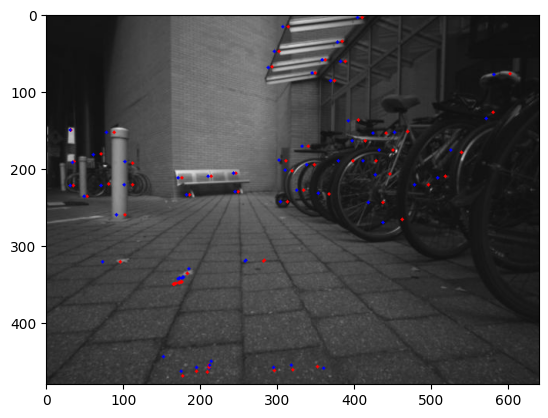

In [6]:
def extract_features(features, img):
    for feature in features:
        for j in range(4):
            if feature[j] != -1:
                # Making the points colorful
                x = int(feature[0])
                y = int(feature[1])
                img = cv2.circle(img, (x, y), 2, (255, 0, 0), -1)

                x = int(feature[2])
                y = int(feature[3])
                img = cv2.circle(img, (x, y), 2, (0, 0, 255), -1)
    return img


def observed_features(lst):
    observed = []
    for i in range(len(lst)):
        for j in range(4):
            if lst[i][j] != -1:
                observed.append(i)
                break
    return np.array(observed)

img = images["cam_imgs_L"][60]
# Converting the image to RGB
img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
# Extracting the features
img = extract_features(features[60], img)
print(img.shape)
# Dataset 00 's first frame with features is 60
plt.imshow(img)
plt.show()

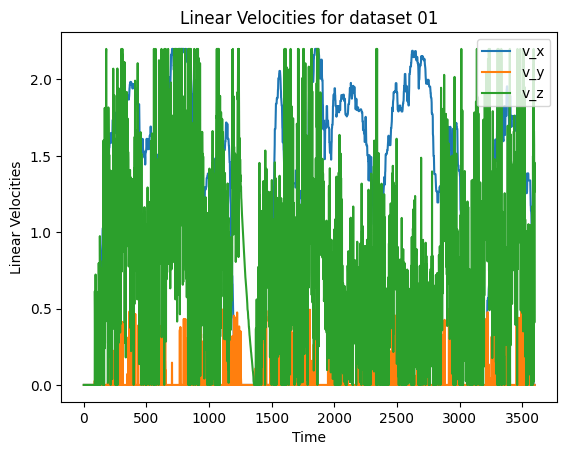

In [7]:
plt.plot(v_t[:, 0], label="v_x")
plt.plot(v_t[:, 1], label="v_y")
plt.plot(v_t[:, 2], label="v_z")

plt.title(f"Linear Velocities for dataset {dataset}")
plt.xlabel("Time")
plt.ylabel("Linear Velocities")
plt.legend()
plt.show()

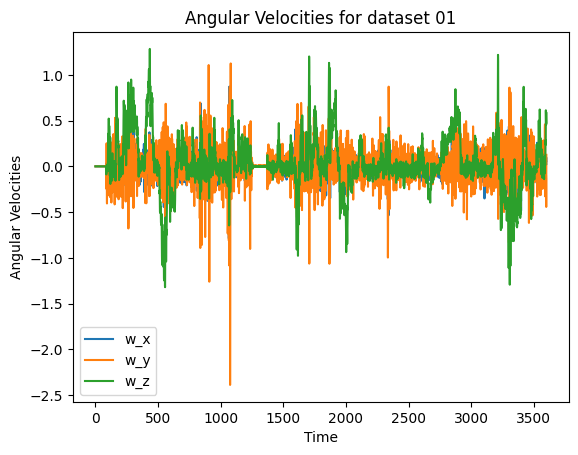

In [8]:
plt.plot(w_t[:, 0], label="w_x")
plt.plot(w_t[:, 1], label="w_y")
plt.plot(w_t[:, 2], label="w_z")

plt.title(f"Angular Velocities for dataset {dataset}")
plt.xlabel("Time")
plt.ylabel("Angular Velocities")
plt.legend()
plt.show()

In [9]:
def motion_model(v, w, dt, noise=0):
    """
    Compute the motion model for the robot
    :param v: linear velocity
    :param w: angular velocity
    :param dt: time step
    :return: the pose of the robot after the motion
    """
    # Compute the twist
    twist = axangle2twist(dt * np.hstack((v, w)))
    pose = twist2pose(twist)
    return pose

/Users/pedramaghazadeh/Desktop/ECE276a/Project3/code/pr3_utils.py:205: RuntimeWarning: invalid value encountered in divide
  Tn = np.nan_to_num(T / rotang)
/Users/pedramaghazadeh/Desktop/ECE276a/Project3/code/pr3_utils.py:205: RuntimeWarning: divide by zero encountered in divide
  Tn = np.nan_to_num(T / rotang)
/Users/pedramaghazadeh/Desktop/ECE276a/Project3/code/pr3_utils.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(pose[:,0,3],pose[:,1,3],'r-',label="Poses", c='r')


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

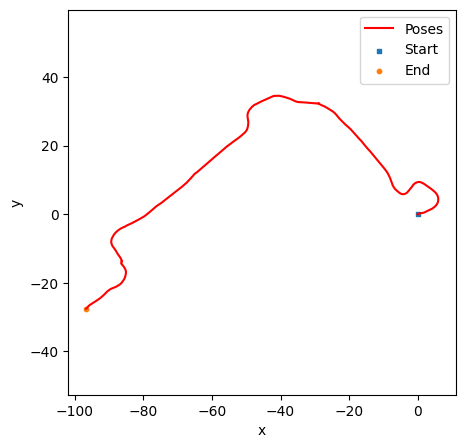

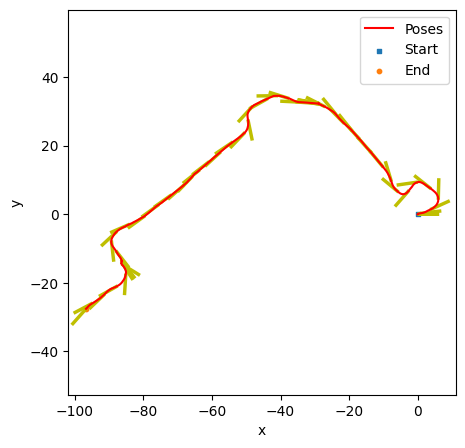

In [10]:
poses = np.zeros((v_t.shape[0], 4, 4))
poses[0] = np.eye(4)
for i in range(1, v_t.shape[0]):
    poses[i] = poses[i - 1] @ motion_model(v_t[i], w_t[i], timestamps[i] - timestamps[i-1])

visualize_trajectory_2d(poses, path_name="Dataset 00")
visualize_trajectory_2d(poses, path_name="Dataset 00 with orientation", show_ori=True)

In [11]:
def hat_map(x):
    """
    Compute the hat map of a vector
    :param x: the vector
    :return: the skew symmetric matrix
    """
    return np.array([[0, -x[2], x[1]],
                     [x[2], 0, -x[0]],
                     [-x[1], x[0], 0]])

# EKF SLAM
def ekf_predict(mu, sigma, v, w, dt):
    """
    EKF prediction step
    :param mu: the mean of the state
    :param sigma: the covariance of the state
    :param v: linear velocity
    :param w: angular velocity
    :param dt: time step
    :return: the predicted mean and covariance
    """
    f = motion_model(v, w, dt * 0.9)
    mu_new = mu @ f
    
    u_hat = np.zeros((6, 6)) 
    u_hat[:3, :3] = hat_map(w)
    u_hat[:3, 3:] = hat_map(v)
    u_hat[3:, 3:] = hat_map(w)

    F = twist2pose(-dt * u_hat)
    sigma_new = F @ sigma @ F.T + dt * W
    return mu_new, sigma_new

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

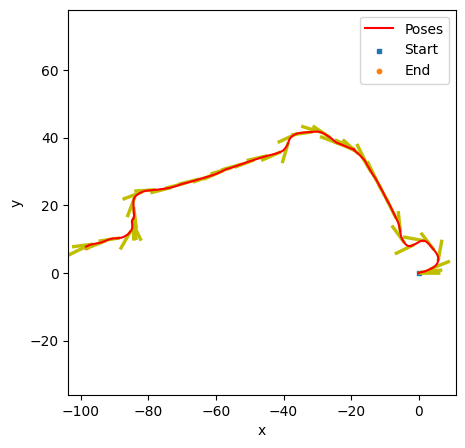

In [12]:
mu_poses = np.zeros((v_t.shape[0], 4, 4))
sigma_pose = np.zeros((v_t.shape[0], 6, 6))
mu_poses[0] = np.eye(4)
sigma_pose[0] = np.eye((6))

for i in range(1, v_t.shape[0]):
    mu_poses[i], sigma_pose[i] = ekf_predict(mu_poses[i - 1], sigma_pose[i - 1], v_t[i], w_t[i], timestamps[i] - timestamps[i - 1])

visualize_trajectory_2d(mu_poses, path_name="EKF Predict only", show_ori=True)

Part c)

In [13]:
opt_T_c = np.zeros((4, 4))
opt_T_c[0, 1] = -1
opt_T_c[1, 2] = -1
opt_T_c[2, 0] = 1
opt_T_c[3, 3] = 1

def pi(x):
    """
    Project x
    :param x: the vector to project
    :return: the projected vector
    """
    return x / x[2]


def jacobian_pi(x):
    """
    Compute the Jacobian of the projection
    :param x: the vector to project
    :return: the Jacobian
    """
    J = np.zeros((4, 4))
    J[0, 0] = 1 / x[2]
    J[1, 1] = 1 / x[2]
    J[0, 2] = -x[0] / x[2]**2
    J[1, 2] = -x[1] / x[2]**2
    J[2, 3] = -x[3] / x[2]**2
    J[3, 3] = 1 / x[2]
    return J

def observation_model(pose, m):
    """
    Compute the observation model
    :param mu: the mean of the state
    :param feature: the feature
    :return: the expected measurement
    """
    # Homogeneous coordinates
    m_ = np.ones(4)
    m_[:3] = m

    pose_inv = np.linalg.inv(pose)
    z = K_s @ pi(opt_T_c @ pose_inv @ m_)

    return z

def jacobian_observation_model(pose, mu):
    """
    Compute the Jacobian of the observation model
    :param mu: the mean of the state"
    """
    # Homogeneous coordinates
    m_ = np.ones(4)
    m_[:3] = mu

    P = np.zeros((3, 4))
    P[:3, :3] = np.eye(3)

    pose_inv = np.linalg.inv(pose)
    jacobian = K_s @ jacobian_pi(opt_T_c @ pose_inv @ m_) @ opt_T_c @ pose_inv @ P.T

    return jacobian

def derivative_se3(x):
    """
    Compute the derivative of the SE3 group
    :param x: the vector
    :return: the derivative
    """
    J = np.zeros((4, 6))
    J[:3, :3] = np.eye(3)
    J[:3, 3:] = -hat_map(x[:3])
    return J

def jacobian_observation_pose(pose, mu):
    """
    Compute the Jacobian of the observation model
    :param mu: the mean of the state"
    """
    # Homogeneous coordinates
    m_ = np.ones(4)
    m_[:3] = mu

    P = np.zeros((3, 4))
    P[:3, :3] = np.eye(3)

    pose_inv = np.linalg.inv(pose)
    jacobian = K_s @ jacobian_pi(opt_T_c @ pose_inv @ m_) @ opt_T_c @ derivative_se3(pose_inv @ m_)

    return jacobian

Triangulation for the initial guess

(3601, 12787, 4) (3601, 4, 4) (38361,)


100%|██████████| 3601/3601 [00:31<00:00, 115.77it/s]


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

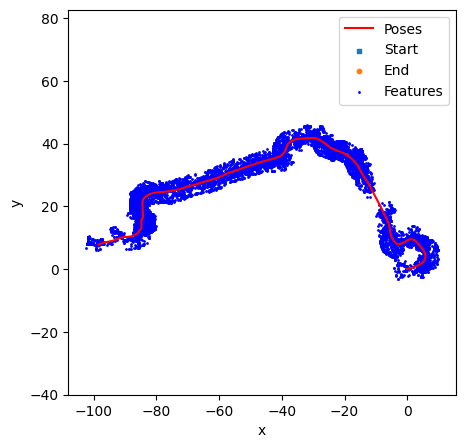

In [ ]:
# # Let's use all features for now
N_feature = features.shape[1]

mu_features = np.zeros((N_feature * 3))
sigma_features = np.eye(N_feature * 3) # Very large covariance, but only 3*3 diagonal blocks
sigma_noise_obs = np.zeros((4 * N_feature, 4 * N_feature))
for j in range(N_feature):
    sigma_noise_obs[4 * j:4 * j + 4, 4 * j:4 * j + 4] = np.eye(4) * obs_noise

extL_T_opt = opt_T_c @ inversePose(extL_T_imu)
extR_T_opt = opt_T_c @ inversePose(extR_T_imu)

p_l = K_l @ extL_T_opt[:3, :]
p_r = K_r @ extR_T_opt[:3, :]

marked = [0] * N_feature
print(features.shape, mu_poses.shape, mu_features.shape)
# Adding the initial guesses
for t in tqdm(range(features.shape[0])):
    pose = mu_poses[t]
    cur_loc = pose[:3, 3]
    for feat in range(N_feature):
        
        u_l, v_l, u_r, v_r = features[t][feat]
        # pose = inversePose(pose)
        # Not found features only!
        if u_l != -1 or u_r != -1 or v_l != -1 or v_r != -1:
            # CV2 method
            l = np.array([[u_l], [v_l]])
            r = np.array([[u_r], [v_r]])

            point = triangulatePoints(p_l, p_r, l, r)
            point = point.flatten() / point[3]

            # Max distance from Robot is 5m
            if np.linalg.norm(point[:3]) > 5:
                point[:3] *= (5 / np.linalg.norm(point[:3]))
            # point = np.clip(point, -100, 100)

            point = pose @ point
            mu_features[3 * feat:3 * feat + 3] = point[:3]

visualize_trajectory_2d(mu_poses, path_name="EKF SLAM with features", show_ori=False, features=mu_features.reshape(-1, 3))

Sanity checking

We don't expect the z values to be good whatsoever

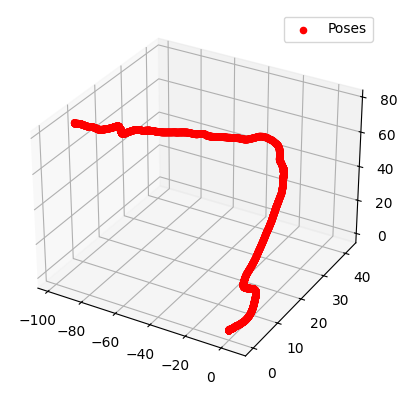

In [34]:
# Visualizing the points in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mu_poses[:, 0, 3], mu_poses[:, 1, 3], mu_poses[:, 2, 3], c='r', marker='o', label="Poses")
ax.legend()
plt.show()

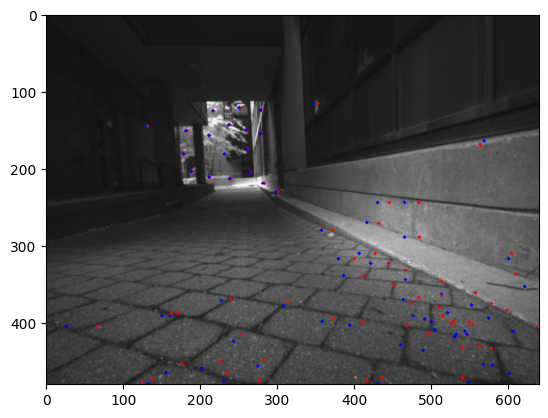

In [16]:
ind = 700
img = images["cam_imgs_L"][ind]
# Converting the image to RGB
img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
# Extracting the features
img = extract_features(features[ind], img)

# Dataset 00 's first frame with features is 60
plt.imshow(img)
plt.show()

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

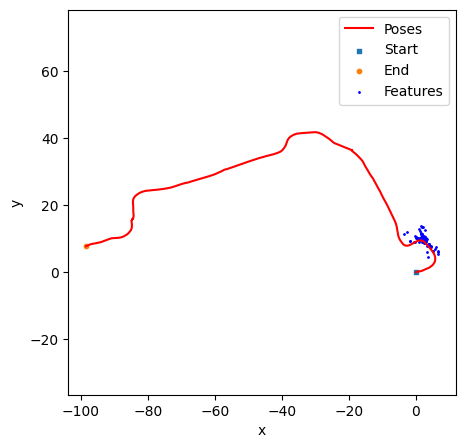

In [17]:
visualize_trajectory_2d(mu_poses, path_name="EKF SLAM with features", show_ori=False, features=mu_features.reshape(-1, 3)[1200:1300])

DON'T INITIALIZE I EVERYTIME! IT TAKES 1SECOND

100%|██████████| 3601/3601 [02:36<00:00, 23.01it/s]


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

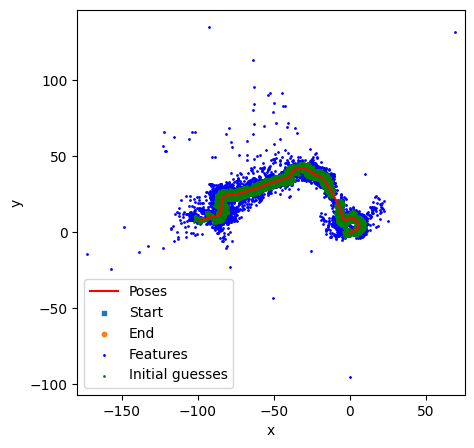

In [35]:
init_features = np.copy(mu_features)

I = csr_matrix(np.eye(N_feature * 3))
for t in tqdm(range(features.shape[0])):
    observed = observed_features(features[t])

    if len(observed) == 0:
        continue

    z = features[t][observed].flatten() # N_t x 4
    z_hat = np.zeros((4 * len(observed)))

    H = lil_matrix((4 * len(observed), 3 * N_feature))
    V = csr_matrix(sigma_noise_obs[: 4 * len(observed), : 4 * len(observed)])

    for idx, feature_idx in enumerate(observed):
        feature_slice = slice(3 * feature_idx, 3 * feature_idx + 3)
        obs_slice = slice(4 * idx, 4 * idx + 4)

        z_hat[obs_slice] = observation_model(mu_poses[t], mu_features[feature_slice])    
        H[obs_slice, feature_slice] = jacobian_observation_model(mu_poses[t], mu_features[feature_slice])

    H = H.tocsr()

    sigma_features = csr_matrix(sigma_features)
    S = H @ sigma_features @ H.T + V
    S_inv = np.linalg.inv(S.toarray())
    K = sigma_features @ H.T @ csr_matrix(S_inv)
    sigma_features = (I - K @ H) @ sigma_features
    mu_features = mu_features + K @ (z - z_hat)

visualize_trajectory_2d(mu_poses, path_name="EKF SLAM with features", show_ori=False, features=mu_features.reshape(-1, 3), features_init=init_features.reshape(-1, 3))
    

Part 4) Combining the Pose with Landmark features

Time taken for S: 0.010365009307861328

Time taken for S_inv: 0.01081395149230957

Time taken for K: 0.32460474967956543

Time taken for sigma: 0.24073100090026855

Time taken for mu: 0.0004820823669433594

Time taken for mu_pose: 0.0005331039428710938

Computing everything again for last part

100%|██████████| 12787/12787 [00:36<00:00, 351.88it/s]


New number of features:  1063


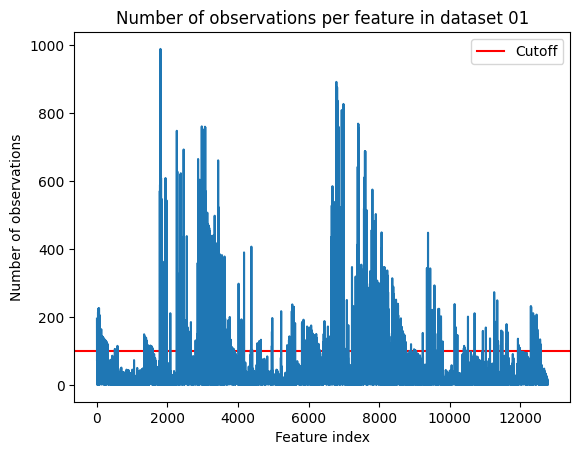

In [36]:
# Using only the most frequently observed features
cutoff = 100

cnt = []
for i in tqdm(range(N_feature)):
    count = 0
    for j in range(len(features)):
        for k in range(4):
            if features[j][i][k] != -1:
                count += 1
                break
    cnt.append(count)

plt.title(f"Number of observations per feature in dataset {dataset}")
plt.xlabel("Feature index")
plt.ylabel("Number of observations")
# Cutoff line
plt.axhline(y=cutoff, color='r', linestyle='-', label="Cutoff")
plt.legend()
plt.plot(cnt)

features_to_keep = np.where(np.array(cnt) > cutoff)[0]
features = features[:, features_to_keep]
N_feature = features.shape[1]
print("New number of features: ", N_feature)

(3601, 1063, 4) (3601, 4, 4) (3189,)


100%|██████████| 3601/3601 [00:03<00:00, 1009.77it/s]


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

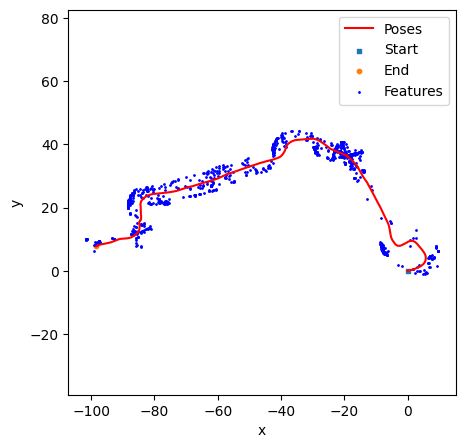

In [ ]:
mu_poses = np.zeros((v_t.shape[0], 4, 4))
sigma_pose = np.zeros((v_t.shape[0], 6, 6))
mu_poses[0] = np.eye(4)
sigma_pose[0] = np.eye((6))

for i in range(1, v_t.shape[0]):
    mu_poses[i], sigma_pose[i] = ekf_predict(mu_poses[i - 1], sigma_pose[i - 1], v_t[i], w_t[i], timestamps[i] - timestamps[i - 1])

# # Let's use all features for now
N_feature = features.shape[1]

mu_features = np.zeros((N_feature * 3))
sigma_features = np.eye(N_feature * 3) # Very large covariance, but only 3*3 diagonal blocks
sigma_noise_obs = np.zeros((4 * N_feature, 4 * N_feature))
for j in range(N_feature):
    sigma_noise_obs[4 * j:4 * j + 4, 4 * j:4 * j + 4] = np.eye(4) * obs_noise

extL_T_opt = opt_T_c @ inversePose(extL_T_imu)
extR_T_opt = opt_T_c @ inversePose(extR_T_imu)

p_l = K_l @ extL_T_opt[:3, :]
p_r = K_r @ extR_T_opt[:3, :]

marked = [0] * N_feature
print(features.shape, mu_poses.shape, mu_features.shape)
# Adding the initial guesses
for t in tqdm(range(features.shape[0])):
    pose = mu_poses[t]
    cur_loc = pose[:3, 3]
    for feat in range(N_feature):
        
        u_l, v_l, u_r, v_r = features[t][feat]
        # pose = inversePose(pose)
        # Not found features only!
        if u_l != -1 or u_r != -1 or v_l != -1 or v_r != -1:
            # CV2 method
            l = np.array([[u_l], [v_l]])
            r = np.array([[u_r], [v_r]])

            point = triangulatePoints(p_l, p_r, l, r)
            point = point.flatten() / point[3]

            # Max distance from Robot is 5m
            if np.linalg.norm(point[:3]) > 5:
                point[:3] *= (5 / np.linalg.norm(point[:3]))

            point = pose @ point
            # Clipping x-values

            mu_features[3 * feat:3 * feat + 3] = point[:3]

visualize_trajectory_2d(mu_poses, path_name="EKF SLAM with features", show_ori=False, features=mu_features.reshape(-1, 3))

In [ ]:
mu_poses_init = np.copy(mu_poses)

mu = np.zeros((N_feature * 3))
mu_poses_init = np.copy(mu_poses)

mu_poses = np.zeros((v_t.shape[0], 4, 4))
mu_pose = np.eye(4)
mu_poses[0] = mu_pose

sigma = np.eye(6 + N_feature * 3)
sigma[:6, :6] *= motion_noise
sigma[6:, 6:] *= obs_noise

I = csr_matrix(np.eye(6 + N_feature * 3))

for t in tqdm(range(features.shape[0])):
    # Prediction only affects the pose
    mu_pose, sigma[:6, :6] = ekf_predict(mu_pose, sigma[:6, :6], v_t[t], w_t[t], timestamps[t] - timestamps[t-1])

    # Update step will affect both pose and features
    observed = observed_features(features[t])

    if len(observed) == 0:
        continue
    z = features[t][observed].flatten() # N_t x 4
    z_hat = np.zeros((4 * len(observed)))

    H = lil_matrix((4 * len(observed), 6 + 3 * N_feature))
    V = csr_matrix(sigma_noise_obs[: 4 * len(observed), : 4 * len(observed)])

    for idx, feature_idx in enumerate(observed):
        feature_slice = slice(3 * feature_idx, 3 * feature_idx + 3)
        obs_slice = slice(4 * idx, 4 * idx + 4)

        z_hat[obs_slice] = observation_model(mu_pose, mu[feature_slice])    
        H[obs_slice, feature_slice] = jacobian_observation_model(mu_pose, mu[feature_slice])
        # Jacobian wrt pose
        H[obs_slice, :6] = jacobian_observation_pose(mu_pose, mu[feature_slice])

    H = H.tocsr()
    # Timing each step
    import time
    start = time.time()
    sigma = csr_matrix(sigma)
    S = H @ sigma @ H.T + V
    # print(f"Time taken for S: {time.time() - start}")
    # start = time.time()

    S_inv = np.linalg.inv(S.toarray())
    # print(f"Time taken for S_inv: {time.time() - start}")
    # start = time.time()

    K = sigma @ H.T @ csr_matrix(S_inv)
    # print(f"Time taken for K: {time.time() - start}")
    # start = time.time()

    sigma = (I - K @ H) @ sigma
    # print(f"Time taken for sigma: {time.time() - start}")
    # start = time.time()

    # Pose's update is different
    mu = mu + (K @ (z - z_hat))[6:]
    # print(f"Time taken for mu: {time.time() - start}")
    # start = time.time()

    # Update the pose
    mu_pose = mu_pose @ twist2pose(axangle2twist(K @ (z - z_hat))[:6])
    mu_poses[t] = mu_pose
    # print(f"Time taken for mu_pose: {time.time() - start}\n")

visualize_trajectory_2d(mu_poses, path_name="EKF SLAM with features", show_ori=False, features=mu_features.reshape(-1, 3), features_init=mu_init.reshape(-1, 3), pose_init=mu_poses_init)